# Assignment 3 – Observable ML with MLflow
### FashionMNIST Garment Classifier — MLflow Experiment Tracking

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms

import mlflow
import mlflow.pytorch

import matplotlib.pyplot as plt
import numpy as np

# ── Device setup (CUDA if available) ──
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Download datasets once
training_set = torchvision.datasets.FashionMNIST('./data', train=True, transform=transform, download=True)
validation_set = torchvision.datasets.FashionMNIST('./data', train=False, transform=transform, download=True)

# Class labels
classes = ('T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot')

print(f'Training set has {len(training_set)} instances')
print(f'Validation set has {len(validation_set)} instances')

Training set has 60000 instances
Validation set has 10000 instances


Trouser  Pullover  Shirt  Shirt


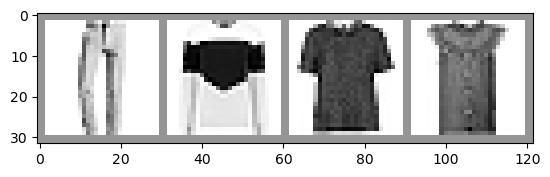

In [3]:
def matplotlib_imshow(img, one_channel=False):
    if one_channel:
        img = img.mean(dim=0)
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    if one_channel:
        plt.imshow(npimg, cmap="Greys")
    else:
        plt.imshow(np.transpose(npimg, (1, 2, 0)))

# Show a few training samples
sample_loader = torch.utils.data.DataLoader(training_set, batch_size=4, shuffle=True)
images, labels = next(iter(sample_loader))
img_grid = torchvision.utils.make_grid(images)
matplotlib_imshow(img_grid, one_channel=True)
print('  '.join(classes[labels[j]] for j in range(4)))

In [4]:
class GarmentClassifier(nn.Module):
    def __init__(self):
        super(GarmentClassifier, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 4 * 4)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [5]:
def train_one_epoch(model, training_loader, optimizer, loss_fn, epoch_index):
    """Train for one epoch, return average loss."""
    model.train(True)
    running_loss = 0.0
    last_loss = 0.0

    for i, (inputs, labels) in enumerate(training_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if i % 1000 == 999:
            last_loss = running_loss / 1000
            print(f'  batch {i + 1} loss: {last_loss:.4f}')
            step = epoch_index * len(training_loader) + i + 1
            mlflow.log_metric('train_batch_loss', last_loss, step=step)
            running_loss = 0.0

    return last_loss


def evaluate(model, validation_loader, loss_fn):
    """Evaluate model, return (avg_loss, accuracy)."""
    model.eval()
    running_vloss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in validation_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            vloss = loss_fn(outputs, labels)
            running_vloss += vloss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_vloss = running_vloss / len(validation_loader)
    accuracy = correct / total
    return avg_vloss, accuracy

## Phase 2 — MLflow Experiment Setup
Set experiment name and define the main training function.

In [6]:
import os

# Force everything into your A3 folder
PROJECT_DIR = r"C:\\Users\\midoh\\Desktop\\UST\Spring\DSAI 406 MLOPS\Assignments\A3"
os.chdir(PROJECT_DIR)
mlflow.set_tracking_uri(f"sqlite:///{os.path.join(PROJECT_DIR, 'mlflow.db')}")

mlflow.set_experiment("Assignment_3_Mohamed_Hozien")

2026/03/10 00:06:27 INFO mlflow.tracking.fluent: Experiment with name 'Assignment_3_Mohamed_Hozien' does not exist. Creating a new experiment.


<Experiment: artifact_location=('file:///C:/Users/midoh/Desktop/UST/Spring/DSAI 406 '
 'MLOPS/Assignments/A3/mlruns/1'), creation_time=1773093987120, experiment_id='1', last_update_time=1773093987120, lifecycle_stage='active', name='Assignment_3_Mohamed_Hozien', tags={}, workspace='default'>

In [7]:
# ──────────────────────────────────────────────
# Set your experiment name (Phase 2 requirement)
# ──────────────────────────────────────────────
# mlflow.set_experiment("Assignment_3_Mohamed_Hozien")


def run_experiment(lr, batch_size, epochs, momentum=0.9, run_name=None):
    """
    Run one full training experiment tracked by MLflow.
    Each call = one row in the MLflow UI.
    """
    # Create data loaders with the given batch_size
    pin = (device.type == 'cuda')
    training_loader = torch.utils.data.DataLoader(
        training_set, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=pin)
    validation_loader = torch.utils.data.DataLoader(
        validation_set, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=pin)

    # Fresh model & optimizer for each run
    model = GarmentClassifier().to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum)
    loss_fn = nn.CrossEntropyLoss()

    with mlflow.start_run(run_name=run_name):
        # ── Log Parameters (at least 3) ──
        mlflow.log_params({
            "learning_rate": lr,
            "batch_size": batch_size,
            "epochs": epochs,
            "momentum": momentum,
            "optimizer": "SGD",
            "loss_function": "CrossEntropyLoss",
        })

        # ── Log Tags ──
        mlflow.set_tag("student_id", "202201507")
        mlflow.set_tag("model_arch", "GarmentClassifier_CNN")
        mlflow.set_tag("device", str(device))

        best_vloss = float('inf')
        best_accuracy = 0.0

        for epoch in range(epochs):
            print(f'EPOCH {epoch + 1}/{epochs}')

            # Train
            avg_train_loss = train_one_epoch(
                model, training_loader, optimizer, loss_fn, epoch)

            # Validate
            avg_vloss, accuracy = evaluate(
                model, validation_loader, loss_fn)

            print(f'  Train Loss: {avg_train_loss:.4f} | '
                  f'Val Loss: {avg_vloss:.4f} | '
                  f'Val Accuracy: {accuracy:.4f}')

            # ── Log Metrics per Epoch (loss + accuracy) ──
            mlflow.log_metric('train_loss', avg_train_loss, step=epoch + 1)
            mlflow.log_metric('val_loss', avg_vloss, step=epoch + 1)
            mlflow.log_metric('val_accuracy', accuracy, step=epoch + 1)

            # Track best model
            if avg_vloss < best_vloss:
                best_vloss = avg_vloss
                best_accuracy = accuracy
                torch.save(model.state_dict(), 'best_model.pth')

        # ── Log Final / Best Metrics ──
        mlflow.log_metric('best_val_loss', best_vloss)
        mlflow.log_metric('best_val_accuracy', best_accuracy)

        # ── Log Model Artifact (MLflow Model Flavor) ──
        mlflow.pytorch.log_model(model, "model")
        mlflow.log_artifact('best_model.pth')

        run_id = mlflow.active_run().info.run_id
        print(f'\nRun complete — MLflow run ID: {run_id}')
        print(f'Best Val Loss: {best_vloss:.4f} | Best Val Accuracy: {best_accuracy:.4f}')

    return run_id

## Phase 3 — Run 5 Experiments with Different Hyperparameters
Each run varies at least one hyperparameter so we can compare in the MLflow UI.

In [8]:
# ─────────────────────────────────────────────────────
# Run 1: Baseline
# ─────────────────────────────────────────────────────
run_experiment(lr=0.001, batch_size=4, epochs=1,
               run_name="Run1_baseline_lr0.001_bs4")

EPOCH 1/1
  batch 1000 loss: 1.6413
  batch 2000 loss: 0.8536
  batch 3000 loss: 0.7066
  batch 4000 loss: 0.6234
  batch 5000 loss: 0.5722
  batch 6000 loss: 0.5307
  batch 7000 loss: 0.5213
  batch 8000 loss: 0.5048
  batch 9000 loss: 0.4754
  batch 10000 loss: 0.4599
  batch 11000 loss: 0.4662
  batch 12000 loss: 0.4421
  batch 13000 loss: 0.4393
  batch 14000 loss: 0.4185
  batch 15000 loss: 0.4109


2026/03/10 00:07:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/10 00:07:23 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


  Train Loss: 0.4109 | Val Loss: 0.4163 | Val Accuracy: 0.8480

Run complete — MLflow run ID: c8d1ea197c9f4ab393f65d5bfbabba99
Best Val Loss: 0.4163 | Best Val Accuracy: 0.8480


'c8d1ea197c9f4ab393f65d5bfbabba99'

In [9]:
# ─────────────────────────────────────────────────────
# Run 2: Higher learning rate
# ─────────────────────────────────────────────────────
run_experiment(lr=0.01, batch_size=4, epochs=1,
               run_name="Run2_lr0.01_bs4")

EPOCH 1/1
  batch 1000 loss: 1.1704
  batch 2000 loss: 0.8222
  batch 3000 loss: 0.8161
  batch 4000 loss: 0.7525
  batch 5000 loss: 0.8030
  batch 6000 loss: 0.7108
  batch 7000 loss: 0.7455
  batch 8000 loss: 0.7134
  batch 9000 loss: 0.6655
  batch 10000 loss: 0.7151
  batch 11000 loss: 0.6920
  batch 12000 loss: 0.7385
  batch 13000 loss: 0.7334
  batch 14000 loss: 0.6684
  batch 15000 loss: 0.6903


2026/03/10 00:08:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/10 00:08:10 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


  Train Loss: 0.6903 | Val Loss: 0.7920 | Val Accuracy: 0.7315

Run complete — MLflow run ID: 0013f66fd7c540beb2b97d305b0349b6
Best Val Loss: 0.7920 | Best Val Accuracy: 0.7315


'0013f66fd7c540beb2b97d305b0349b6'

In [10]:
# ─────────────────────────────────────────────────────
# Run 3: Even higher learning rate (potential instability)
# ─────────────────────────────────────────────────────
run_experiment(lr=0.1, batch_size=4, epochs=1,
               run_name="Run3_lr0.1_bs4")

EPOCH 1/1
  batch 1000 loss: 2.3555
  batch 2000 loss: 2.3560
  batch 3000 loss: 2.3571
  batch 4000 loss: 2.3621
  batch 5000 loss: 2.3608
  batch 6000 loss: 2.3585
  batch 7000 loss: 2.3655
  batch 8000 loss: 2.3595
  batch 9000 loss: 2.3634
  batch 10000 loss: 2.3595
  batch 11000 loss: 2.3557
  batch 12000 loss: 2.3599
  batch 13000 loss: 2.3578
  batch 14000 loss: 2.3557
  batch 15000 loss: 2.3645


2026/03/10 00:08:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/10 00:08:54 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


  Train Loss: 2.3645 | Val Loss: 2.3499 | Val Accuracy: 0.1000

Run complete — MLflow run ID: ed882b84071249e686cf93e9d1f71c76
Best Val Loss: 2.3499 | Best Val Accuracy: 0.1000


'ed882b84071249e686cf93e9d1f71c76'

In [11]:
# ─────────────────────────────────────────────────────
# Run 4: Larger batch size
# ─────────────────────────────────────────────────────
run_experiment(lr=0.01, batch_size=64, epochs=1,
               run_name="Run4_lr0.01_bs64")

EPOCH 1/1


2026/03/10 00:09:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/10 00:09:28 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


  Train Loss: 0.0000 | Val Loss: 0.4887 | Val Accuracy: 0.8202

Run complete — MLflow run ID: 2e860273978c4ea7938d72c8dc9ad9de
Best Val Loss: 0.4887 | Best Val Accuracy: 0.8202


'2e860273978c4ea7938d72c8dc9ad9de'

In [12]:
# ─────────────────────────────────────────────────────
# Run 5: Larger batch size + more epochs
# ─────────────────────────────────────────────────────
run_experiment(lr=0.01, batch_size=64, epochs=5,
               run_name="Run5_lr0.01_bs64_ep10")

EPOCH 1/5
  Train Loss: 0.0000 | Val Loss: 0.4445 | Val Accuracy: 0.8345
EPOCH 2/5
  Train Loss: 0.0000 | Val Loss: 0.3848 | Val Accuracy: 0.8608
EPOCH 3/5
  Train Loss: 0.0000 | Val Loss: 0.3613 | Val Accuracy: 0.8698
EPOCH 4/5
  Train Loss: 0.0000 | Val Loss: 0.3423 | Val Accuracy: 0.8715
EPOCH 5/5


2026/03/10 00:10:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/10 00:10:33 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


  Train Loss: 0.0000 | Val Loss: 0.3295 | Val Accuracy: 0.8809

Run complete — MLflow run ID: 207fcc1d9aaf440da2dc214611ee6e49
Best Val Loss: 0.3295 | Best Val Accuracy: 0.8809


'207fcc1d9aaf440da2dc214611ee6e49'

## Load the Best Model
After reviewing the MLflow UI, paste the best run's ID below to reload the model.

In [ ]:
# Option A: Load from .pth file (last run's best)
saved_model = GarmentClassifier().to(device)
saved_model.load_state_dict(torch.load('best_model.pth', map_location=device))
print("Model loaded from best_model.pth")

# Option B: Load from MLflow (replace RUN_ID with actual ID from UI)
# saved_model = mlflow.pytorch.load_model("runs:/<RUN_ID>/model")